# GAN with Keras on Fashion MNIST

This notebook implements a Generative Adversarial Network (GAN) using TensorFlow/Keras to generate Fashion MNIST images.

Based on: https://colab.research.google.com/github/qaazii/3D-Bounding-Boxes-From-Monocular-Images/blob/master/Intro-to-Generative-Adversarial-Network/Tensorflow/GAN_Tensorflow_Fashion_MNIST.ipynb

In [1]:
!pip install numpy==1.19.2
!pip install tensorflow
!pip install torch==1.7.0
!pip install torchsummary==1.5.1
!pip install torchvision==0.8.1
!pip install matplotlib
!pip install ipython

  Using cached numpy-1.19.2.zip (7.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\commands\install.py", line 392, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir
    )
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 99, in resolve
    result = self._result = resolver.resolve(
                            

ERROR: Could not find a version that satisfies the requirement torch==1.7.0 (from versions: 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==1.7.0


ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.8.1 (from versions: 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0)
ERROR: No matching distribution found for torchvision==0.8.1


In [2]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow import keras

In [3]:
print('TensorFlow version:', tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    mixed_precision.set_global_policy('mixed_float16')
    tf.config.optimizer.set_jit(True)  # XLA JIT for extra acceleration
    print(f'GPU detected: {len(gpus)}')
    print('Mixed precision policy:', mixed_precision.global_policy())
else:
    print('No GPU detected. Running on CPU with float32.')

TensorFlow version: 2.21.0
No GPU detected. Running on CPU with float32.


## Load and Preprocess Data

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_train = (x_train - 127.5) / 127.5  # Normalize the images to [-1, 1]

# Batch and shuffle the data
BUFFER_SIZE = 60000
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(AUTOTUNE)
)

print('Training data shape:', x_train.shape)

Training data shape: (60000, 28, 28, 1)


## Hyperparameters

In [5]:
latent_dim = 100
image_dim = 784  # 28 * 28
num_examples_to_generate = 25
learning_rate = 0.0002

# Training setup for report comparison
BASELINE_EPOCHS = 60
DCGAN_EPOCHS = 60
VIS_INTERVAL = 10

# Reuse fixed seeds for fair before/after comparison
seed = tf.random.normal([num_examples_to_generate, latent_dim])
baseline_seed = tf.random.normal([num_examples_to_generate, latent_dim])
dcgan_seed = tf.random.normal([num_examples_to_generate, latent_dim])

## Generator Model

The generator takes a random noise vector (latent space) as input and produces a 28x28x1 image.

In [6]:
def build_generator(image_dim):
    inputs = keras.Input(shape=(100,), name='input_layer')
    x = layers.Dense(128, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_1')(inputs)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_2')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_3')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_3')(x)
    x = layers.Dense(1024, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_4')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_3')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_4')(x)
    x = layers.Dense(image_dim, kernel_initializer=tf.keras.initializers.he_uniform(), activation='tanh', name='dense_5')(x)
    outputs = layers.Reshape((28, 28, 1), name='Reshape_Layer')(x)
    model = tf.keras.Model(inputs, outputs, name='Generator')
    return model

generator = build_generator(image_dim)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_3 (LeakyReLU)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_4 (LeakyReLU)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_Layer (Reshape)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,513,616 (5.77 MB)

 Trainable params: 1,510,032 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

## Discriminator Model

The discriminator takes a 28x28x1 image as input and outputs a probability indicating whether the image is real or fake.

In [7]:
def build_discriminator():
    inputs = keras.Input(shape=(28, 28, 1), name='input_layer')
    x = layers.Flatten(name='flatten_layer')(inputs)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    outputs = layers.Dense(
        1,
        kernel_initializer=tf.keras.initializers.he_uniform(),
        activation='sigmoid',
        dtype='float32',
        name='dense_3'
    )(x)
    model = tf.keras.Model(inputs, outputs, name='Discriminator')
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Loss Functions

In [8]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return binary_cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = binary_cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

## Optimizers

In [9]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)

## Checkpoints

In [10]:
checkpoint_dir = './training_checkpoints_baseline'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

## Training Step

In [11]:
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

## Image Generation and Saving

In [12]:
os.makedirs('generated_images', exist_ok=True)

def generate_and_save_images(model, epoch, test_input, output_dir='generated_images', title_prefix='Baseline GAN'):
    os.makedirs(output_dir, exist_ok=True)
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(5, 5))
    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i + 1)
        pred = (predictions[i, :, :, 0] + 1) * 127.5
        pred = np.array(pred)
        plt.imshow(pred.astype(np.uint8), cmap='gray')
        plt.axis('off')

    plt.suptitle(f'{title_prefix} - Epoch {epoch}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/image_at_epoch_{epoch:04d}.png')
    plt.show()

## Training Loop

In [13]:
def train(dataset, epochs, vis_interval=10):
    gen_losses, disc_losses = [], []

    generate_and_save_images(generator, 0, baseline_seed, output_dir='generated_images_baseline', title_prefix='Baseline GAN')

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_loss = tf.keras.metrics.Mean()
        epoch_disc_loss = tf.keras.metrics.Mean()

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_loss.update_state(gen_loss)
            epoch_disc_loss.update_state(disc_loss)

        gen_losses.append(float(epoch_gen_loss.result().numpy()))
        disc_losses.append(float(epoch_disc_loss.result().numpy()))

        if (epoch + 1) % vis_interval == 0 or epoch == 0 or (epoch + 1) == epochs:
            display.clear_output(wait=True)
            generate_and_save_images(
                generator,
                epoch + 1,
                baseline_seed,
                output_dir='generated_images_baseline',
                title_prefix='Baseline GAN'
            )

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(
            f'Baseline Epoch {epoch + 1:03d}/{epochs:03d} | '
            f'g_loss={gen_losses[-1]:.4f} d_loss={disc_losses[-1]:.4f} | '
            f'time={time.time() - start:.2f}s'
        )

    return {'g_loss': gen_losses, 'd_loss': disc_losses}

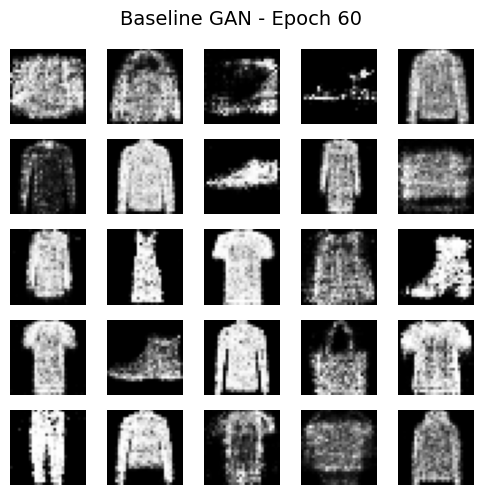

Baseline Epoch 060/060 | g_loss=0.7808 d_loss=1.3275 | time=4.57s


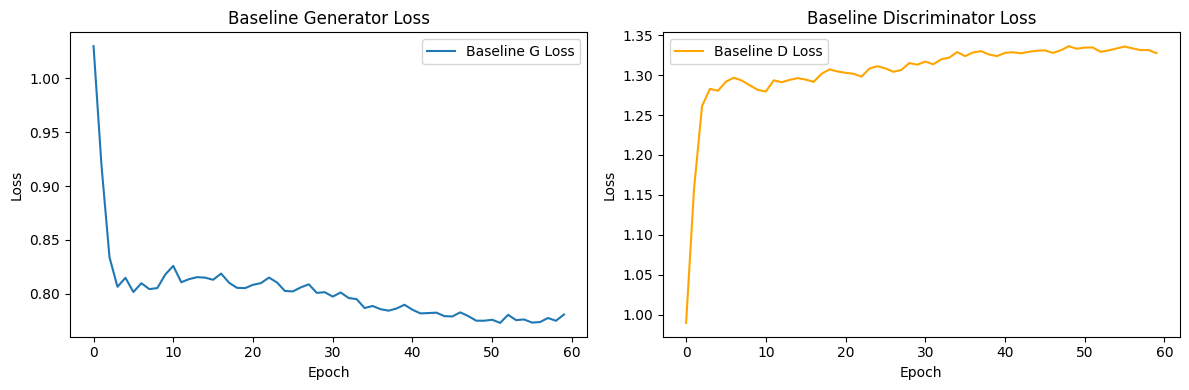

In [14]:
baseline_history = train(train_dataset, BASELINE_EPOCHS, vis_interval=VIS_INTERVAL)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history['g_loss'], label='Baseline G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Generator Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history['d_loss'], label='Baseline D Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Discriminator Loss')
plt.legend()
plt.tight_layout()
plt.show()

## DCGAN Model Improvements

### What changed from baseline GAN

1. Generator: replaced Dense stack with Conv2DTranspose upsampling blocks.
2. Discriminator: replaced Flatten + Dense with Conv2D downsampling blocks + Dropout.
3. Training stability: used one-sided label smoothing on real images.
4. Fair comparison: same latent dimension and same number of epochs as baseline.

In [15]:
def build_dcgan_generator(latent_dim=100):
    inputs = keras.Input(shape=(latent_dim,), name='dcgan_noise')
    x = layers.Dense(7 * 7 * 256, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh')(x)
    return keras.Model(inputs, outputs, name='DCGAN_Generator')

def build_dcgan_discriminator():
    inputs = keras.Input(shape=(28, 28, 1), name='dcgan_image')
    x = layers.Conv2D(64, kernel_size=5, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, kernel_size=5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='DCGAN_Discriminator')

dcgan_generator = build_dcgan_generator(latent_dim=latent_dim)
dcgan_discriminator = build_dcgan_discriminator()

dcgan_generator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)
dcgan_discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)

dcgan_checkpoint_dir = './training_checkpoints_dcgan'
dcgan_checkpoint_prefix = os.path.join(dcgan_checkpoint_dir, 'ckpt')
dcgan_checkpoint = tf.train.Checkpoint(
    generator_optimizer=dcgan_generator_optimizer,
    discriminator_optimizer=dcgan_discriminator_optimizer,
    generator=dcgan_generator,
    discriminator=dcgan_discriminator
)

dcgan_generator.summary()
dcgan_discriminator.summary()

Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dcgan_noise (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dcgan_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

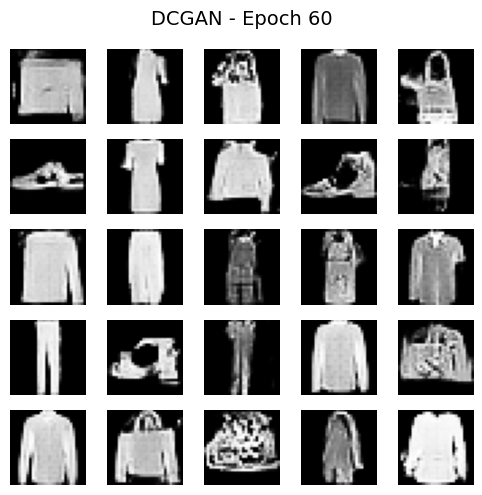

DCGAN Epoch 060/060 | g_loss=0.8863 d_loss=1.3273 | time=32.05s


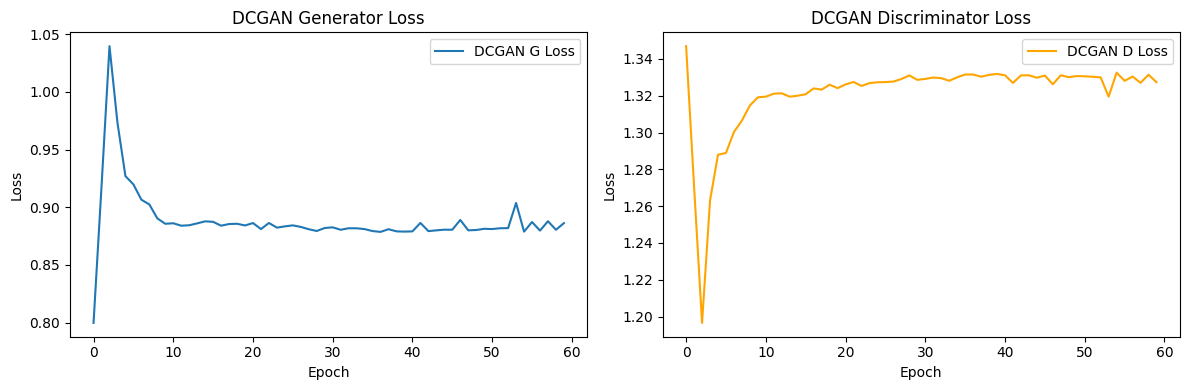

In [16]:
@tf.function
def train_step_dcgan(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = dcgan_generator(noise, training=True)

        real_output = dcgan_discriminator(images, training=True)
        fake_output = dcgan_discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        real_labels = tf.ones_like(real_output) * 0.9  # one-sided label smoothing
        real_loss = binary_cross_entropy(real_labels, real_output)
        fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    gradients_of_gen = gen_tape.gradient(gen_loss, dcgan_generator.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, dcgan_discriminator.trainable_variables)

    dcgan_generator_optimizer.apply_gradients(zip(gradients_of_gen, dcgan_generator.trainable_variables))
    dcgan_discriminator_optimizer.apply_gradients(zip(gradients_of_disc, dcgan_discriminator.trainable_variables))

    return gen_loss, disc_loss

def train_dcgan(dataset, epochs, vis_interval=10):
    gen_losses, disc_losses = [], []

    generate_and_save_images(
        dcgan_generator,
        0,
        dcgan_seed,
        output_dir='generated_images_dcgan',
        title_prefix='DCGAN'
    )

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_loss = tf.keras.metrics.Mean()
        epoch_disc_loss = tf.keras.metrics.Mean()

        for image_batch in dataset:
            gen_loss, disc_loss = train_step_dcgan(image_batch)
            epoch_gen_loss.update_state(gen_loss)
            epoch_disc_loss.update_state(disc_loss)

        gen_losses.append(float(epoch_gen_loss.result().numpy()))
        disc_losses.append(float(epoch_disc_loss.result().numpy()))

        if (epoch + 1) % vis_interval == 0 or epoch == 0 or (epoch + 1) == epochs:
            display.clear_output(wait=True)
            generate_and_save_images(
                dcgan_generator,
                epoch + 1,
                dcgan_seed,
                output_dir='generated_images_dcgan',
                title_prefix='DCGAN'
            )

        if (epoch + 1) % 15 == 0:
            dcgan_checkpoint.save(file_prefix=dcgan_checkpoint_prefix)

        print(
            f'DCGAN Epoch {epoch + 1:03d}/{epochs:03d} | '
            f'g_loss={gen_losses[-1]:.4f} d_loss={disc_losses[-1]:.4f} | '
            f'time={time.time() - start:.2f}s'
        )

    return {'g_loss': gen_losses, 'd_loss': disc_losses}

dcgan_history = train_dcgan(train_dataset, DCGAN_EPOCHS, vis_interval=VIS_INTERVAL)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dcgan_history['g_loss'], label='DCGAN G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Generator Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dcgan_history['d_loss'], label='DCGAN D Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Discriminator Loss')
plt.legend()
plt.tight_layout()
plt.show()

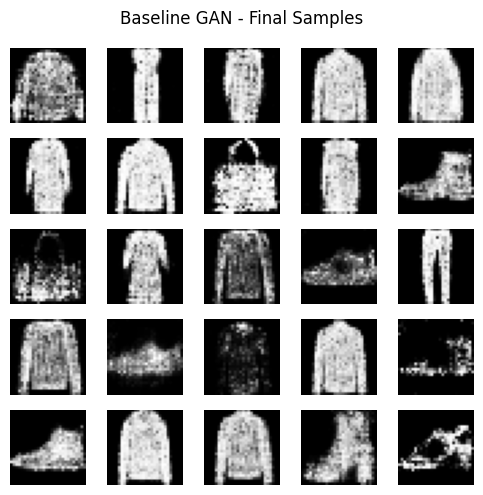

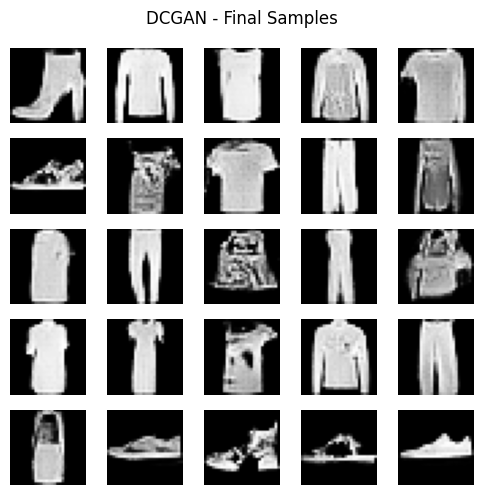

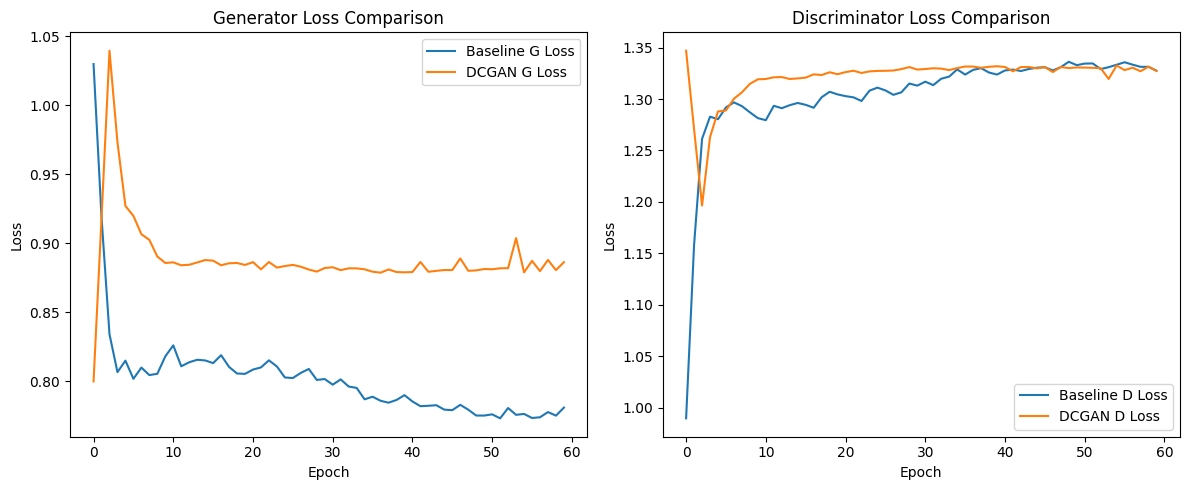

Pixel Std (higher usually means richer variation): baseline=0.7450, dcgan=0.7655


In [17]:
def show_model_samples(model, title, test_input):
    preds = model(test_input, training=False)
    fig = plt.figure(figsize=(5, 5))
    for i in range(preds.shape[0]):
        plt.subplot(5, 5, i + 1)
        pred = (preds[i, :, :, 0] + 1) * 127.5
        plt.imshow(pred.numpy().astype(np.uint8), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_model_samples(generator, 'Baseline GAN - Final Samples', seed)
show_model_samples(dcgan_generator, 'DCGAN - Final Samples', seed)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(baseline_history['g_loss'], label='Baseline G Loss')
plt.plot(dcgan_history['g_loss'], label='DCGAN G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history['d_loss'], label='Baseline D Loss')
plt.plot(dcgan_history['d_loss'], label='DCGAN D Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss Comparison')
plt.legend()
plt.tight_layout()
plt.show()

baseline_final_fake = generator(seed, training=False)
dcgan_final_fake = dcgan_generator(seed, training=False)

baseline_std = float(tf.math.reduce_std(baseline_final_fake).numpy())
dcgan_std = float(tf.math.reduce_std(dcgan_final_fake).numpy())
print(f'Pixel Std (higher usually means richer variation): baseline={baseline_std:.4f}, dcgan={dcgan_std:.4f}')